# 04 - AG com SMOTE — Oversampling como alternativa ao sample_weight

Testa se substituir `sample_weight=balanced` por **SMOTE** (Synthetic Minority
Oversampling Technique) melhora o modelo no threshold operacional 0.40.

**Diferença central em relação aos notebooks anteriores:**
- 01_AG, 02, 03: usam `sample_weight=balanced` para lidar com o desbalanceamento
- **04**: usa SMOTE dentro do CV — cria amostras sintéticas da classe minoritária
  (prematuros) em cada fold de treino, sem vazar informação para o fold de teste

**4 experimentos variando o tipo de SMOTE:**

| Experimento | SMOTE | k_neighbors | AG config |
|---|---|---|---|
| Exp1 | SMOTE padrão | 5 | Padrão |
| Exp2 | SMOTE padrão | 5 | Hot start (seed = baseline Fase 1) |
| Exp3 | SMOTE | 10 | Padrão |
| Exp4 | BorderlineSMOTE | 5 | Padrão |

BorderlineSMOTE foca nas amostras da fronteira de decisão (mais difíceis de classificar),
podendo capturar padrões que o SMOTE padrão ignora.

In [1]:
import gc
import json
import math
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# path setup antes de qualquer import local
_SRC_DIR = Path('../src').resolve()
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

from pipeline import apply_scenario

In [2]:
SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

warnings.filterwarnings('ignore')

RANDOM_STATE          = 42
CV_SPLITS             = 3
MIN_RECALL_THRESHOLD  = 0.80
OPERATIONAL_THRESHOLD = 0.40
SCENARIO              = 'B'

DATA_DIR      = Path('../data')
METRICS_DIR   = Path('../results/metrics')
ARTIFACTS_DIR = Path('../results/artifacts')
FIGURES_DIR   = Path('../results/figures')

N_JOBS = max(1, (os.cpu_count() - 4) // 2)
print(f'CPUs disponíveis : {os.cpu_count()}')
print(f'N_JOBS (04)     : {N_JOBS}  — reserva 4 cores para uso pessoal')

CPUs disponíveis : 12
N_JOBS (05d)     : 4  — reserva 4 cores para uso pessoal


In [3]:
def load_scenario_data(scenario: str) -> tuple:
    X_train_full = pd.read_parquet(DATA_DIR / 'X_train.parquet')
    X_test_full  = pd.read_parquet(DATA_DIR / 'X_test.parquet')
    y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet').iloc[:, 0]
    y_test  = pd.read_parquet(DATA_DIR / 'y_test.parquet').iloc[:, 0]
    X_train = apply_scenario(X_train_full, scenario)
    X_test  = apply_scenario(X_test_full,  scenario)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_scenario_data(SCENARIO)
print('X_train:', X_train.shape, '| y_train positivos:', y_train.sum())

X_train: (562520, 26) | y_train positivos: 62274


## Baseline (Fase 1 — sem SMOTE, com sample_weight)

In [4]:
from sklearn.utils.class_weight import compute_sample_weight

METRIC_NAMES = ['recall', 'f2', 'precision', 'roc_auc', 'average_precision', 'brier']

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold':         float(threshold),
        'recall':            recall_score(y_true, y_pred, zero_division=0),
        'f2':                fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'f1':                f1_score(y_true, y_pred, zero_division=0),
        'precision':         precision_score(y_true, y_pred, zero_division=0),
        'roc_auc':           roc_auc_score(y_true, y_prob),
        'average_precision': average_precision_score(y_true, y_prob),
        'brier':             brier_score_loss(y_true, y_prob),
    }

def evaluate_histgb_on_test(params: dict, threshold: float = OPERATIONAL_THRESHOLD,
                             use_sample_weight: bool = True) -> dict:
    model = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    if use_sample_weight:
        sw = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight=sw)
    else:
        model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_prob, threshold=threshold)

def evaluate_smote_pipeline_on_test(params: dict, smote_instance,
                                    threshold: float = OPERATIONAL_THRESHOLD) -> dict:
    pipeline = ImbPipeline([
        ('smote', smote_instance),
        ('clf',   HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)),
    ])
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_prob, threshold=threshold)

BASELINE_PARAMS = json.loads(
    (METRICS_DIR / 'best_model_operational_metrics.json').read_text()
)['best_params']

baseline_metrics = evaluate_histgb_on_test(BASELINE_PARAMS)
print('=== BASELINE (Fase 1, sample_weight, threshold 0.40) ===')
for m in METRIC_NAMES:
    print(f'  {m:20s}: {baseline_metrics[m]:.4f}')
gc.collect()

=== BASELINE (Fase 1, sample_weight, threshold 0.40) ===
  recall              : 0.9743
  f2                  : 0.3857
  precision           : 0.1129
  roc_auc             : 0.5773
  average_precision   : 0.1507
  brier               : 0.2436


24

## Scorers customizados (threshold 0.40) e configurações de SMOTE

O SMOTE é aplicado **dentro de cada fold de treino** pelo `ImbPipeline` — a classe
minoritária sintética nunca contamina o fold de avaliação. Isso é a diferença
fundamental entre `imblearn.pipeline.Pipeline` e aplicar SMOTE antes do CV.

Sem `sample_weight`: o SMOTE já equilibra as classes, aplicar peso adicional
seria dupla penalização da maioria.

In [5]:
FITNESS_PENALTY = -1.0
_cv_strategy = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def _recall_at_operational(y_true, y_prob, **kwargs):
    return recall_score((y_prob >= OPERATIONAL_THRESHOLD).astype(int),
                        (y_prob >= OPERATIONAL_THRESHOLD).astype(int), zero_division=0)

def _recall_at_operational(y_true, y_prob, **kwargs):
    y_pred = (y_prob >= OPERATIONAL_THRESHOLD).astype(int)
    return recall_score(y_true, y_pred, zero_division=0)

def _f2_at_operational(y_true, y_prob, **kwargs):
    y_pred = (y_prob >= OPERATIONAL_THRESHOLD).astype(int)
    return fbeta_score(y_true, y_pred, beta=2, zero_division=0)

_recall_scorer_040 = make_scorer(_recall_at_operational, needs_proba=True)
_f2_scorer_040     = make_scorer(_f2_at_operational,     needs_proba=True)

SMOTE_CONFIGS = {
    'SMOTE_k5':           SMOTE(k_neighbors=5,  sampling_strategy=0.3, random_state=RANDOM_STATE),
    'SMOTE_k10':          SMOTE(k_neighbors=10, sampling_strategy=0.3, random_state=RANDOM_STATE),
    'BorderlineSMOTE_k5': BorderlineSMOTE(k_neighbors=5, sampling_strategy=0.3, random_state=RANDOM_STATE),
}
print('SMOTE configs:', list(SMOTE_CONFIGS.keys()))

SMOTE configs: ['SMOTE_k5', 'SMOTE_k10', 'BorderlineSMOTE_k5']


## Espaço de busca (8 genes — mesmo do 03)

In [6]:
SEARCH_SPACE: dict = {
    'max_iter':          [100, 150, 200, 250, 300, 350, 400, 500],
    'learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2],
    'max_leaf_nodes':    [15, 23, 31, 47, 63, 95, 127],
    'min_samples_leaf':  [10, 20, 35, 50, 75, 100, 150],
    'l2_regularization': [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'max_depth':         [None, 3, 5, 7, 10, 15],
    'max_bins':          [63, 127, 255],
}

PARAM_NAMES  = list(SEARCH_SPACE.keys())
PARAM_VALUES = list(SEARCH_SPACE.values())
N_GENES      = len(PARAM_NAMES)

def decode(individual: np.ndarray) -> dict:
    return {PARAM_NAMES[i]: PARAM_VALUES[i][individual[i]] for i in range(N_GENES)}

def random_individual(rng: np.random.Generator) -> np.ndarray:
    return np.array([rng.integers(0, len(v)) for v in PARAM_VALUES])

# max_iter=350→5, lr=0.05→2, max_leaf_nodes=31→2, min_samples_leaf=100→5
# l2=1.0→4, max_depth=None→0, max_bins=255→2
_baseline_individual = np.array([5, 2, 2, 5, 4, 0, 2])
print('Baseline params:', decode(_baseline_individual))

Baseline params: {'max_iter': 350, 'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': 1.0, 'max_depth': None, 'max_bins': 255}


## Função fitness (SMOTE pipeline)

In [7]:
def fitness(individual: np.ndarray, smote_instance,
            min_recall_threshold: float = MIN_RECALL_THRESHOLD) -> float:
    params   = decode(individual)
    pipeline = ImbPipeline([
        ('smote', smote_instance),
        ('clf',   HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)),
    ])
    mean_recall = cross_val_score(
        pipeline, X_train, y_train, cv=_cv_strategy,
        scoring=_recall_scorer_040, n_jobs=1,
    ).mean()
    mean_f2 = cross_val_score(
        pipeline, X_train, y_train, cv=_cv_strategy,
        scoring=_f2_scorer_040, n_jobs=1,
    ).mean()
    return float(mean_f2) if mean_recall >= min_recall_threshold else float(mean_recall) + FITNESS_PENALTY

In [8]:
# Verificação: baseline com SMOTE_k5 deve passar o piso de 0.80
_smote_ref = SMOTE_CONFIGS['SMOTE_k5']
_f_base    = fitness(_baseline_individual, _smote_ref)
print(f'Fitness baseline (SMOTE_k5): {_f_base:.4f}')
print(f'Positivo = AG já parte da zona de F2' if _f_base > 0 else 'Negativo = zona de penalidade')

Fitness baseline (SMOTE_k5): -0.9958
Negativo = zona de penalidade


## Operadores genéticos

In [9]:
def tournament_selection(population, fitnesses, tournament_size, rng):
    candidates   = rng.choice(len(population), size=tournament_size, replace=False)
    winner_index = candidates[np.argmax([fitnesses[i] for i in candidates])]
    return population[winner_index].copy()

def single_point_crossover(parent_a, parent_b, crossover_rate, rng):
    if rng.random() > crossover_rate:
        return parent_a.copy(), parent_b.copy()
    cut = rng.integers(1, N_GENES)
    return (
        np.concatenate([parent_a[:cut], parent_b[cut:]]),
        np.concatenate([parent_b[:cut], parent_a[cut:]]),
    )

def mutate(individual, mutation_rate, rng):
    mutated = individual.copy()
    for i in range(N_GENES):
        if rng.random() < mutation_rate:
            mutated[i] = rng.integers(0, len(PARAM_VALUES[i]))
    return mutated

## Loop principal do AG

In [10]:
def _initialize_population(pop_size, rng, seed_individual=None):
    pop = [seed_individual.copy()] if seed_individual is not None else []
    pop += [random_individual(rng) for _ in range(pop_size - len(pop))]
    return pop

def _evaluate_population(population, smote_instance, min_recall_threshold=MIN_RECALL_THRESHOLD):
    return Parallel(n_jobs=N_JOBS)(
        delayed(fitness)(ind, smote_instance, min_recall_threshold) for ind in population
    )

def _breed_next_generation(population, fitnesses, pop_size, elite_size,
                           tournament_size, crossover_rate, mutation_rate, rng):
    sorted_idx = np.argsort(fitnesses)[::-1]
    next_gen   = [population[i].copy() for i in sorted_idx[:elite_size]]
    while len(next_gen) < pop_size:
        pa = tournament_selection(population, fitnesses, tournament_size, rng)
        pb = tournament_selection(population, fitnesses, tournament_size, rng)
        ca, cb = single_point_crossover(pa, pb, crossover_rate, rng)
        next_gen.append(mutate(ca, mutation_rate, rng))
        if len(next_gen) < pop_size:
            next_gen.append(mutate(cb, mutation_rate, rng))
    return next_gen

def run_genetic_algorithm(
    smote_instance,
    pop_size=20, n_generations=15, mutation_rate=0.20, crossover_rate=0.80,
    tournament_size=3, elite_size=1, seed=RANDOM_STATE, label='AG',
    min_recall_threshold=MIN_RECALL_THRESHOLD, seed_individual=None,
) -> dict:
    rng        = np.random.default_rng(seed)
    population = _initialize_population(pop_size, rng, seed_individual)
    best_individual, best_fitness_ever = None, -np.inf
    history_rows = []

    for gen in range(1, n_generations + 1):
        fitnesses = _evaluate_population(population, smote_instance, min_recall_threshold)
        best_idx  = int(np.argmax(fitnesses))
        best_fit  = fitnesses[best_idx]
        if best_fit > best_fitness_ever:
            best_fitness_ever = best_fit
            best_individual   = population[best_idx].copy()
        history_rows.append({
            'generation':   gen,
            'best_fitness': best_fit,
            'mean_fitness': float(np.mean(fitnesses)),
            'best_params':  decode(population[best_idx]),
        })
        print(f'[{label}] Gen {gen}/{n_generations} | melhor={best_fit:.4f} | média={np.mean(fitnesses):.4f}')
        population = _breed_next_generation(
            population, fitnesses, pop_size, elite_size,
            tournament_size, crossover_rate, mutation_rate, rng,
        )

    return {
        'label':           label,
        'best_params':     decode(best_individual),
        'best_cv_fitness': best_fitness_ever,
        'smote':           type(smote_instance).__name__,
        'history':         pd.DataFrame(history_rows),
    }

In [11]:
_smoke = run_genetic_algorithm(
    smote_instance=SMOTE_CONFIGS['SMOTE_k5'],
    pop_size=4, n_generations=2, label='smoke_04',
)
print('\nSmoke OK | params:', _smoke['best_params'])
print(f'Fitness : {_smoke["best_cv_fitness"]:.4f}')

[smoke_05d] Gen 1/2 | melhor=-0.9915 | média=-0.9945
[smoke_05d] Gen 2/2 | melhor=-0.9877 | média=-0.9915

Smoke OK | params: {'max_iter': 350, 'learning_rate': 0.15, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 2.0, 'max_depth': 15, 'max_bins': 127}
Fitness : -0.9877


## Experimentos — 4 variantes de SMOTE | recall >= 0.80 | threshold 0.40

In [12]:
# Cada experimento combina uma variante de SMOTE com uma config de AG
EXPERIMENTS = [
    dict(
        label='Exp1_SMOTE_k5_padrao',
        smote_key='SMOTE_k5',
        pop_size=8, n_generations=8, mutation_rate=0.20, crossover_rate=0.80,
        seed_individual=None,
    ),
    dict(
        label='Exp2_SMOTE_k5_hotstart',
        smote_key='SMOTE_k5',
        pop_size=8, n_generations=8, mutation_rate=0.20, crossover_rate=0.80,
        seed_individual=_baseline_individual,
    ),
    dict(
        label='Exp3_SMOTE_k10_padrao',
        smote_key='SMOTE_k10',
        pop_size=8, n_generations=8, mutation_rate=0.20, crossover_rate=0.80,
        seed_individual=None,
    ),
    dict(
        label='Exp4_BorderlineSMOTE_padrao',
        smote_key='BorderlineSMOTE_k5',
        pop_size=8, n_generations=8, mutation_rate=0.20, crossover_rate=0.80,
        seed_individual=None,
    ),
]

In [13]:
experiment_results: dict = {}

for exp in EXPERIMENTS:
    label     = exp['label']
    smote_key = exp['smote_key']
    smote     = SMOTE_CONFIGS[smote_key]
    config    = {k: v for k, v in exp.items() if k not in ('label', 'smote_key')}
    print(f'\n{"="*60}\nIniciando {label} | SMOTE: {smote_key}\n{"="*60}')
    result = run_genetic_algorithm(
        smote_instance=smote, label=label,
        min_recall_threshold=MIN_RECALL_THRESHOLD,
        seed=RANDOM_STATE, **config,
    )
    experiment_results[label] = result
    print(f'Params : {result["best_params"]}')
    print(f'Fitness: {result["best_cv_fitness"]:.4f}')


Iniciando Exp1_SMOTE_k5_padrao | SMOTE: SMOTE_k5
[Exp1_SMOTE_k5_padrao] Gen 1/8 | melhor=-0.9915 | média=-0.9943
[Exp1_SMOTE_k5_padrao] Gen 2/8 | melhor=-0.9837 | média=-0.9922
[Exp1_SMOTE_k5_padrao] Gen 3/8 | melhor=-0.9818 | média=-0.9888
[Exp1_SMOTE_k5_padrao] Gen 4/8 | melhor=-0.9796 | média=-0.9870
[Exp1_SMOTE_k5_padrao] Gen 5/8 | melhor=-0.9784 | média=-0.9833
[Exp1_SMOTE_k5_padrao] Gen 6/8 | melhor=-0.9784 | média=-0.9829
[Exp1_SMOTE_k5_padrao] Gen 7/8 | melhor=-0.9784 | média=-0.9841
[Exp1_SMOTE_k5_padrao] Gen 8/8 | melhor=-0.9758 | média=-0.9852
Params : {'max_iter': 400, 'learning_rate': 0.2, 'max_leaf_nodes': 95, 'min_samples_leaf': 100, 'l2_regularization': 5.0, 'max_depth': None, 'max_bins': 63}
Fitness: -0.9758

Iniciando Exp2_SMOTE_k5_hotstart | SMOTE: SMOTE_k5
[Exp2_SMOTE_k5_hotstart] Gen 1/8 | melhor=-0.9915 | média=-0.9948
[Exp2_SMOTE_k5_hotstart] Gen 2/8 | melhor=-0.9842 | média=-0.9931
[Exp2_SMOTE_k5_hotstart] Gen 3/8 | melhor=-0.9842 | média=-0.9912
[Exp2_SMOTE_k5

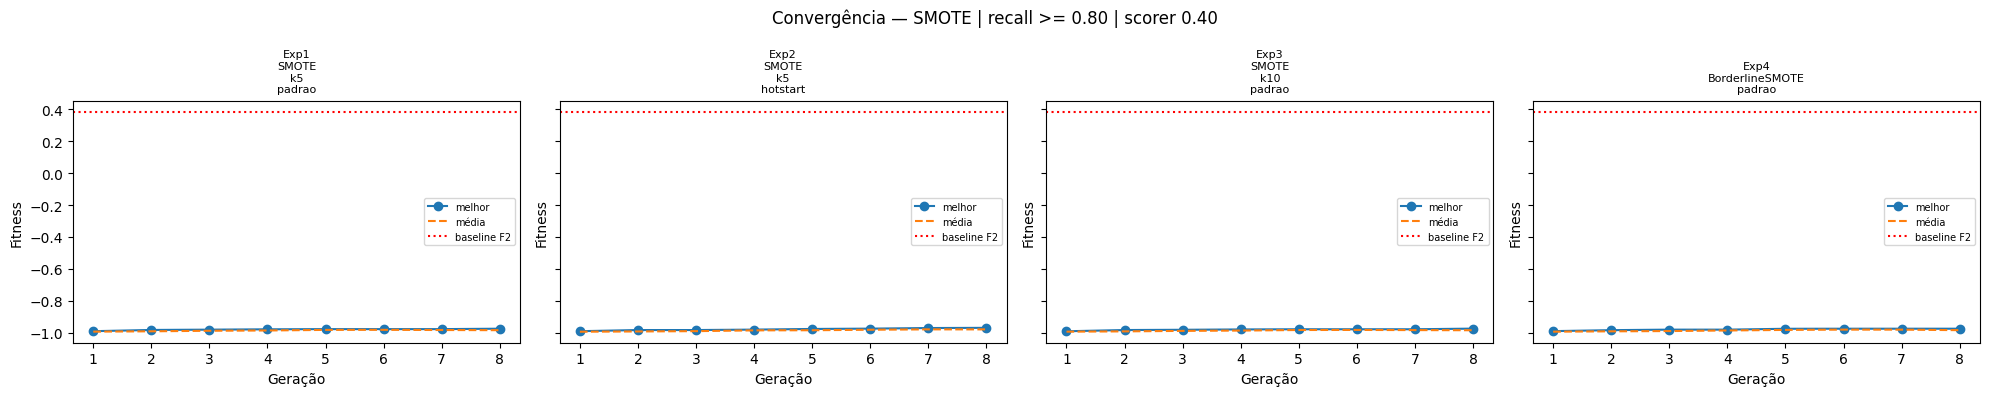

In [14]:
n_exp = len(experiment_results)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4), sharey=True)
for ax, (label, result) in zip(axes, experiment_results.items()):
    h = result['history']
    ax.plot(h['generation'], h['best_fitness'], marker='o', label='melhor')
    ax.plot(h['generation'], h['mean_fitness'], linestyle='--', label='média')
    ax.axhline(baseline_metrics['f2'], color='red', linestyle=':', linewidth=1.5, label='baseline F2')
    ax.set_title(label.replace('_', '\n'), fontsize=8)
    ax.set_xlabel('Geração')
    ax.set_ylabel('Fitness')
    ax.legend(fontsize=7)
plt.suptitle('Convergência — SMOTE | recall >= 0.80 | scorer 0.40', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_convergence_smote.png', dpi=150)
plt.show()

## Comparativo: baseline (sample_weight) vs SMOTE variants

In [15]:
def build_row(label, params, cv_fitness, smote_instance=None):
    if smote_instance is not None:
        m = evaluate_smote_pipeline_on_test(params, smote_instance)
    else:
        m = evaluate_histgb_on_test(params)
    return {'origem': label, 'cv_fitness': round(cv_fitness, 4),
            **{k: m[k] for k in METRIC_NAMES}}

rows = [build_row('Baseline (sample_weight)', BASELINE_PARAMS, 0.0)]

for exp in EXPERIMENTS:
    label  = exp['label']
    result = experiment_results[label]
    smote  = SMOTE_CONFIGS[exp['smote_key']]
    rows.append(build_row(label, result['best_params'], result['best_cv_fitness'], smote))

comparison_df = pd.DataFrame(rows).set_index('origem')
print('=== SMOTE vs sample_weight | threshold 0.40 ===')
display(comparison_df.round(4))
comparison_df.to_csv(METRICS_DIR / '04_comparison_smote.csv')
print(f'Salvo: {METRICS_DIR / "04_comparison_smote.csv"}')
gc.collect()

=== SMOTE vs sample_weight | threshold 0.40 ===


,cv_fitness,recall,f2,precision,roc_auc,average_precision,brier
origem,,,,,,,
Baseline (sample_weight),0.0000,0.9743,0.3857,0.1129,0.5773,0.1507,0.2436
Exp1_SMOTE_k5_padrao,-0.9758,0.0535,0.0627,0.1996,0.5622,0.1415,0.1096
Exp2_SMOTE_k5_hotstart,-0.9705,0.0615,0.0713,0.1968,0.5599,0.1415,0.1101
Exp3_SMOTE_k10_padrao,-0.9753,0.0541,0.0634,0.2010,0.5632,0.1427,0.1087
Exp4_BorderlineSMOTE_padrao,-0.9758,0.0495,0.0585,0.2120,0.5632,0.1434,0.1076


Salvo: ../../results/metrics/05d_comparison_smote.csv


56

In [16]:
MAX_FP_GROWTH_PCT = 0.15
MAX_FN_GROWTH_PCT = 0.30
MIN_RECALL_TEST   = 0.80

baseline_row = comparison_df.loc['Baseline (sample_weight)']
best_exp     = comparison_df.drop('Baseline (sample_weight)').sort_values('f2', ascending=False).iloc[0]
delta_f2     = best_exp['f2'] - baseline_row['f2']
n_pos        = int(y_test.sum())
fn_base      = int(n_pos * (1 - baseline_row['recall']))
fn_ag        = int(n_pos * (1 - best_exp['recall']))
tp_base      = n_pos - fn_base
tp_ag        = n_pos - fn_ag
fp_base      = int(tp_base / max(baseline_row['precision'], 1e-9) - tp_base)
fp_ag        = int(tp_ag   / max(best_exp['precision'],    1e-9) - tp_ag)
fp_growth    = (fp_ag - fp_base) / max(fp_base, 1)
fn_growth    = (fn_ag - fn_base) / max(abs(fn_base), 1)
recall_ok    = best_exp['recall'] >= MIN_RECALL_TEST
fn_ok        = fn_growth <= MAX_FN_GROWTH_PCT
fp_ok        = fp_growth <= MAX_FP_GROWTH_PCT
validacao_ok = recall_ok and fn_ok and fp_ok

print(f'Melhor SMOTE variant: {best_exp.name}')
print(f'F2       : {best_exp["f2"]:.4f}  (baseline {baseline_row["f2"]:.4f} | delta {delta_f2:+.4f})')
print(f'Recall   : {best_exp["recall"]:.4f}  (baseline {baseline_row["recall"]:.4f})')
print(f'ROC-AUC  : {best_exp["roc_auc"]:.4f}  (baseline {baseline_row["roc_auc"]:.4f})')
print(f'\nFN  base={fn_base:,}  AG={fn_ag:,}  crescimento={fn_growth:+.1%}')
print(f'FP  base={fp_base:,}  AG={fp_ag:,}  crescimento={fp_growth:+.1%}')
print(f'\nValidação clínica:')
print(f'  Recall >= {MIN_RECALL_TEST}     : {"OK" if recall_ok else "FALHA"}')
print(f'  FN cresce <= {MAX_FN_GROWTH_PCT:.0%} : {"OK" if fn_ok else "FALHA"}  ({fn_growth:+.1%})')
print(f'  FP cresce <= {MAX_FP_GROWTH_PCT:.0%} : {"OK" if fp_ok else "FALHA"}  ({fp_growth:+.1%})')
print(f'\nSMOTE melhora sobre sample_weight? {"SIM" if delta_f2 > 0.01 else "Melhoria marginal" if delta_f2 > 0 else "NAO"}')
print(f'Pivô: {"APROVADO" if validacao_ok else "REPROVADO"}')

Melhor SMOTE variant: Exp2_SMOTE_k5_hotstart
F2       : 0.0713  (baseline 0.3857 | delta -0.3144)
Recall   : 0.0615  (baseline 0.9743)
ROC-AUC  : 0.5599  (baseline 0.5773)

FN  base=399  AG=14,611  crescimento=+3561.9%
FP  base=119,197  AG=3,905  crescimento=-96.7%

Validação clínica:
  Recall >= 0.8     : FALHA
  FN cresce <= 30% : FALHA  (+3561.9%)
  FP cresce <= 15% : OK  (-96.7%)

SMOTE melhora sobre sample_weight? NAO
Pivô: REPROVADO
